In [84]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [85]:
import numpy as np
import pandas as pd
import gradio as gri
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import gradio as gr
import os
import warnings
warnings.filterwarnings("ignore")

In [86]:
df=pd.read_csv("telesurgery_cybersecurity_dataset.csv")
df

,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
0,10,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption,1
1,8,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption,1
2,9,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN,0
3,1,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection,1
4,4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,Diagnosis,"(0.48, 1.06, 0.4)",2025-02-14 16:32:27,1.39,Idle,10047,Operator,Robot,Two Fish,Encrypted,7,41,Man-in-the-Middle Attack,High,3.47,Reconnect Connection,1
996,9,Navigation,"(1.81, 0.37, 0.3)",2025-02-14 16:32:27,2.11,Idle,66498,Operator,Robot,Two Fish,Failed,14,26,Data Breach,Medium,3.89,Isolate Data,1
997,9,Navigation,"(1.05, 1.83, 0.49)",2025-02-14 16:32:27,2.09,Idle,69106,Operator,Robot,Two Fish,Failed,8,20,Man-in-the-Middle Attack,High,1.83,Reconnect Connection,1
998,1,Navigation,"(1.56, 0.67, 1.91)",2025-02-14 16:32:27,1.01,Idle,94269,Robot,Operator,Two Fish,Encrypted,8,14,No Threat,Medium,0.00,NaN,0


In [87]:
df.head(5)

,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
0,10,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption,1
1,8,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption,1
2,9,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN,0
3,1,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection,1
4,4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data,1


In [88]:
df.tail(5)

,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
995,1,Diagnosis,"(0.48, 1.06, 0.4)",2025-02-14 16:32:27,1.39,Idle,10047,Operator,Robot,Two Fish,Encrypted,7,41,Man-in-the-Middle Attack,High,3.47,Reconnect Connection,1
996,9,Navigation,"(1.81, 0.37, 0.3)",2025-02-14 16:32:27,2.11,Idle,66498,Operator,Robot,Two Fish,Failed,14,26,Data Breach,Medium,3.89,Isolate Data,1
997,9,Navigation,"(1.05, 1.83, 0.49)",2025-02-14 16:32:27,2.09,Idle,69106,Operator,Robot,Two Fish,Failed,8,20,Man-in-the-Middle Attack,High,1.83,Reconnect Connection,1
998,1,Navigation,"(1.56, 0.67, 1.91)",2025-02-14 16:32:27,1.01,Idle,94269,Robot,Operator,Two Fish,Encrypted,8,14,No Threat,Medium,0.00,NaN,0
999,3,Diagnosis,"(0.17, 0.95, 1.23)",2025-02-14 16:32:27,1.60,Idle,11134,Operator,Robot,Two Fish,Encrypted,17,39,DoS Attack,Low,2.36,Reconnect Connection,1


In [89]:
df.info

<bound method DataFrame.info of      Robot Gesture ID Gesture Type Gesture Coordinates (x, y, z)  \
0                  10     Incision             (1.48, 1.4, 0.02)   
1                   8    Diagnosis            (1.62, 1.81, 0.68)   
2                   9     Incision            (0.67, 1.53, 0.06)   
3                   1     Incision            (1.63, 1.74, 1.92)   
4                   4     Suturing            (0.53, 0.87, 1.17)   
..                ...          ...                           ...   
995                 1    Diagnosis             (0.48, 1.06, 0.4)   
996                 9   Navigation             (1.81, 0.37, 0.3)   
997                 9   Navigation            (1.05, 1.83, 0.49)   
998                 1   Navigation            (1.56, 0.67, 1.91)   
999                 3    Diagnosis            (0.17, 0.95, 1.23)   

               Timestamp  Gesture Duration (sec) Robot Status  Message ID  \
0    2025-02-14 16:32:27                    4.37         Idle       22614 

In [90]:
df.describe

<bound method NDFrame.describe of      Robot Gesture ID Gesture Type Gesture Coordinates (x, y, z)  \
0                  10     Incision             (1.48, 1.4, 0.02)   
1                   8    Diagnosis            (1.62, 1.81, 0.68)   
2                   9     Incision            (0.67, 1.53, 0.06)   
3                   1     Incision            (1.63, 1.74, 1.92)   
4                   4     Suturing            (0.53, 0.87, 1.17)   
..                ...          ...                           ...   
995                 1    Diagnosis             (0.48, 1.06, 0.4)   
996                 9   Navigation             (1.81, 0.37, 0.3)   
997                 9   Navigation            (1.05, 1.83, 0.49)   
998                 1   Navigation            (1.56, 0.67, 1.91)   
999                 3    Diagnosis            (0.17, 0.95, 1.23)   

               Timestamp  Gesture Duration (sec) Robot Status  Message ID  \
0    2025-02-14 16:32:27                    4.37         Idle       2261

In [91]:
df.describe()

,Robot Gesture ID,Gesture Duration (sec),Message ID,Network Latency (ms),Data Transfer Rate (Mbps),Response Time (sec),Threat Detected
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,5.453000,3.042100,54765.611000,12.379000,53.693000,2.142390,0.717000
std,2.887582,1.182367,25882.536138,4.566203,26.175139,1.650706,0.450682
min,1.000000,1.000000,10047.000000,5.000000,10.000000,0.000000,0.000000
25%,3.000000,2.000000,32551.000000,8.000000,31.000000,0.000000,0.000000
50%,5.000000,3.075000,54926.500000,12.000000,53.000000,2.240000,1.000000
75%,8.000000,4.082500,76859.000000,16.000000,76.000000,3.525000,1.000000
max,10.000000,5.000000,99857.000000,20.000000,100.000000,4.990000,1.000000


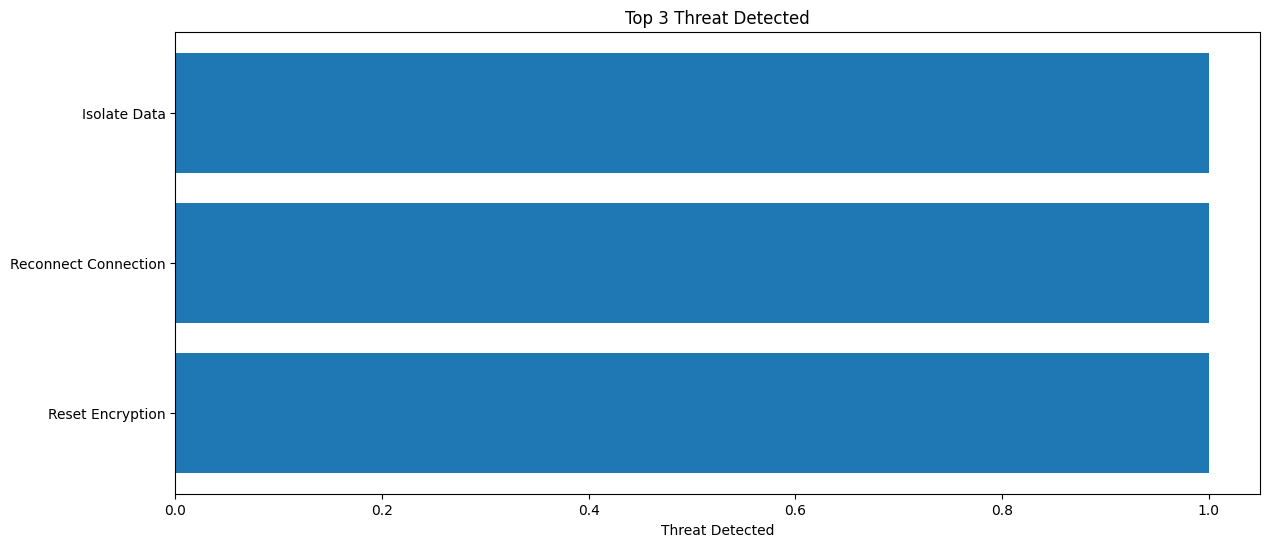

In [92]:
plt.figure(figsize=(14,6))
grouped = df.groupby("Response Action Taken")["Threat Detected"].max().reset_index()
getdata = grouped.sort_values(by="Threat Detected", ascending=False).head(3)
x = getdata["Threat Detected"]
y = getdata["Response Action Taken"]
plt.barh(y, x)
plt.xlabel("Threat Detected")
plt.title("Top 3 Threat Detected")
plt.gca().invert_yaxis()
plt.show()

In [93]:
df.isnull().sum()

Robot Gesture ID                   0
Gesture Type                       0
Gesture Coordinates (x, y, z)      0
Timestamp                          0
Gesture Duration (sec)             0
Robot Status                       0
Message ID                         0
Sender                             0
Receiver                           0
Encryption Algorithm Used          0
Encryption Status                  0
Network Latency (ms)               0
Data Transfer Rate (Mbps)          0
Threat Type                        0
Threat Severity                    0
Response Time (sec)                0
Response Action Taken            283
Threat Detected                    0
dtype: int64

In [94]:
print(df.duplicated())

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


In [95]:
df.drop_duplicates(inplace=True)
df

,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
0,10,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption,1
1,8,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption,1
2,9,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN,0
3,1,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection,1
4,4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,Diagnosis,"(0.48, 1.06, 0.4)",2025-02-14 16:32:27,1.39,Idle,10047,Operator,Robot,Two Fish,Encrypted,7,41,Man-in-the-Middle Attack,High,3.47,Reconnect Connection,1
996,9,Navigation,"(1.81, 0.37, 0.3)",2025-02-14 16:32:27,2.11,Idle,66498,Operator,Robot,Two Fish,Failed,14,26,Data Breach,Medium,3.89,Isolate Data,1
997,9,Navigation,"(1.05, 1.83, 0.49)",2025-02-14 16:32:27,2.09,Idle,69106,Operator,Robot,Two Fish,Failed,8,20,Man-in-the-Middle Attack,High,1.83,Reconnect Connection,1
998,1,Navigation,"(1.56, 0.67, 1.91)",2025-02-14 16:32:27,1.01,Idle,94269,Robot,Operator,Two Fish,Encrypted,8,14,No Threat,Medium,0.00,NaN,0


In [96]:
X=pd.get_dummies(pd.DataFrame(x), drop_first=True)
df.head()

,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
0,10,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption,1
1,8,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption,1
2,9,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN,0
3,1,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection,1
4,4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data,1


In [97]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = LabelEncoder().fit_transform(df[col])
df.head()

,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
0,10,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption,1
1,8,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption,1
2,9,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN,0
3,1,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection,1
4,4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data,1


In [98]:
x=df.drop(['Robot Gesture ID','Threat Detected'],axis=1)
x

,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken
0,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption
1,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption
2,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN
3,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection
4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Diagnosis,"(0.48, 1.06, 0.4)",2025-02-14 16:32:27,1.39,Idle,10047,Operator,Robot,Two Fish,Encrypted,7,41,Man-in-the-Middle Attack,High,3.47,Reconnect Connection
996,Navigation,"(1.81, 0.37, 0.3)",2025-02-14 16:32:27,2.11,Idle,66498,Operator,Robot,Two Fish,Failed,14,26,Data Breach,Medium,3.89,Isolate Data
997,Navigation,"(1.05, 1.83, 0.49)",2025-02-14 16:32:27,2.09,Idle,69106,Operator,Robot,Two Fish,Failed,8,20,Man-in-the-Middle Attack,High,1.83,Reconnect Connection
998,Navigation,"(1.56, 0.67, 1.91)",2025-02-14 16:32:27,1.01,Idle,94269,Robot,Operator,Two Fish,Encrypted,8,14,No Threat,Medium,0.00,NaN


In [99]:
df.rename(columns={'Threat Detected': 'ThreatDetected'}, inplace=True)

In [100]:
y=df.ThreatDetected
y

0      1
1      1
2      0
3      1
4      1
      ..
995    1
996    1
997    1
998    0
999    1
Name: ThreatDetected, Length: 1000, dtype: int64

In [101]:
from sklearn.model_selection import train_test_split

In [102]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=4)

In [103]:
x_train

,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken
608,Cleaning,"(0.08, 0.41, 1.75)",2025-02-14 16:32:27,3.94,Active,31433,Operator,Robot,Two Fish,Failed,12,48,DoS Attack,Medium,2.85,Reset Encryption
511,Cleaning,"(1.29, 2.0, 0.16)",2025-02-14 16:32:27,1.01,Active,15268,Operator,Robot,Two Fish,Failed,16,92,DoS Attack,Low,1.73,Isolate Data
641,Cleaning,"(1.47, 1.16, 0.26)",2025-02-14 16:32:27,1.70,Idle,83955,Robot,Operator,Two Fish,Encrypted,8,57,DoS Attack,High,3.51,Reset Encryption
112,Suturing,"(0.24, 1.14, 1.36)",2025-02-14 16:32:27,1.45,Active,74900,Operator,Robot,Two Fish,Encrypted,10,65,No Threat,Low,0.00,NaN
535,Cleaning,"(1.44, 1.43, 1.38)",2025-02-14 16:32:27,4.65,Idle,83716,Operator,Robot,Two Fish,Failed,18,84,No Threat,Low,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
897,Incision,"(0.46, 0.84, 1.03)",2025-02-14 16:32:27,2.40,Idle,56531,Robot,Operator,Two Fish,Encrypted,10,57,No Threat,High,0.00,NaN
709,Cleaning,"(1.5, 0.2, 1.32)",2025-02-14 16:32:27,3.46,Active,36500,Robot,Operator,Two Fish,Failed,17,81,No Threat,High,0.00,NaN
439,Diagnosis,"(0.14, 1.29, 1.0)",2025-02-14 16:32:27,1.98,Idle,88672,Operator,Robot,Two Fish,Failed,12,96,DoS Attack,Low,1.80,Isolate Data
174,Navigation,"(1.91, 0.25, 1.65)",2025-02-14 16:32:27,2.82,Idle,16674,Operator,Robot,Two Fish,Failed,18,58,DoS Attack,Low,2.48,Reset Encryption


In [104]:
x_test

,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken
698,Suturing,"(1.1, 0.1, 1.84)",2025-02-14 16:32:27,4.88,Active,12882,Robot,Operator,Two Fish,Failed,6,21,Man-in-the-Middle Attack,High,3.26,Reset Encryption
577,Cleaning,"(1.88, 0.35, 0.47)",2025-02-14 16:32:27,3.27,Idle,43099,Robot,Operator,Two Fish,Failed,13,41,Man-in-the-Middle Attack,Low,3.02,Reset Encryption
763,Diagnosis,"(0.65, 0.81, 1.63)",2025-02-14 16:32:27,4.54,Active,37765,Robot,Operator,Two Fish,Failed,16,83,No Threat,High,0.00,NaN
790,Cleaning,"(0.05, 1.98, 0.86)",2025-02-14 16:32:27,4.95,Idle,89624,Operator,Robot,Two Fish,Encrypted,16,56,Man-in-the-Middle Attack,Medium,1.79,Isolate Data
520,Suturing,"(0.22, 0.69, 0.4)",2025-02-14 16:32:27,1.40,Active,19844,Operator,Robot,Two Fish,Encrypted,8,37,DoS Attack,High,1.20,Isolate Data
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Cleaning,"(0.32, 0.07, 0.01)",2025-02-14 16:32:27,1.62,Active,90545,Robot,Operator,Two Fish,Failed,8,13,Man-in-the-Middle Attack,High,2.02,Reconnect Connection
924,Suturing,"(0.89, 1.41, 1.4)",2025-02-14 16:32:27,4.54,Active,71649,Robot,Operator,Two Fish,Encrypted,7,99,Man-in-the-Middle Attack,High,3.16,Isolate Data
632,Cleaning,"(1.21, 1.24, 0.12)",2025-02-14 16:32:27,2.12,Active,53477,Robot,Operator,Two Fish,Encrypted,12,32,No Threat,High,0.00,NaN
869,Cleaning,"(0.72, 1.41, 1.63)",2025-02-14 16:32:27,1.22,Active,35206,Operator,Robot,Two Fish,Encrypted,6,74,DoS Attack,Medium,2.92,Isolate Data


In [105]:
y_train

608    1
511    1
641    1
112    0
535    0
      ..
897    0
709    0
439    1
174    1
122    1
Name: ThreatDetected, Length: 800, dtype: int64

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
x = pd.get_dummies(x, drop_first=True)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)
print("Train Accuracy:", model.score(x_train, y_train))
print("Test Accuracy:", model.score(x_test, y_test))


Train Accuracy: 1.0
Test Accuracy: 1.0


In [107]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode all object/string columns
for col in x_train.columns:
    if x_train[col].dtype == 'object':
        x_train[col] = le.fit_transform(x_train[col].astype(str))
        x_test[col] = le.transform(x_test[col].astype(str))

# Train model
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [108]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [109]:
y_pred = model.predict(x_test)

In [110]:
print("random",model)

random RandomForestClassifier(random_state=42)


In [111]:
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00       150

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion Matrix:
 [[ 50   0]
 [  0 150]]


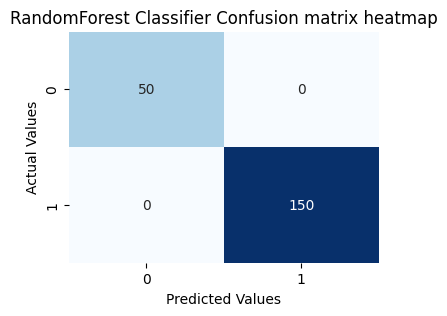

In [112]:
cm=confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("RandomForest Classifier Confusion matrix heatmap")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [113]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [114]:
df=pd.read_csv("telesurgery_cybersecurity_dataset.csv")
df

,Robot Gesture ID,Gesture Type,"Gesture Coordinates (x, y, z)",Timestamp,Gesture Duration (sec),Robot Status,Message ID,Sender,Receiver,Encryption Algorithm Used,Encryption Status,Network Latency (ms),Data Transfer Rate (Mbps),Threat Type,Threat Severity,Response Time (sec),Response Action Taken,Threat Detected
0,10,Incision,"(1.48, 1.4, 0.02)",2025-02-14 16:32:27,4.37,Idle,22614,Operator,Robot,Two Fish,Encrypted,11,97,Man-in-the-Middle Attack,Low,4.63,Reset Encryption,1
1,8,Diagnosis,"(1.62, 1.81, 0.68)",2025-02-14 16:32:27,3.08,Idle,61556,Operator,Robot,Two Fish,Encrypted,9,88,DoS Attack,Low,3.94,Reset Encryption,1
2,9,Incision,"(0.67, 1.53, 0.06)",2025-02-14 16:32:27,1.11,Active,27848,Operator,Robot,Two Fish,Encrypted,7,26,No Threat,Low,0.00,NaN,0
3,1,Incision,"(1.63, 1.74, 1.92)",2025-02-14 16:32:27,2.72,Idle,60592,Operator,Robot,Two Fish,Encrypted,13,56,Data Breach,High,4.58,Reconnect Connection,1
4,4,Suturing,"(0.53, 0.87, 1.17)",2025-02-14 16:32:27,1.20,Idle,46712,Robot,Operator,Two Fish,Failed,5,41,Man-in-the-Middle Attack,Low,2.46,Isolate Data,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,Diagnosis,"(0.48, 1.06, 0.4)",2025-02-14 16:32:27,1.39,Idle,10047,Operator,Robot,Two Fish,Encrypted,7,41,Man-in-the-Middle Attack,High,3.47,Reconnect Connection,1
996,9,Navigation,"(1.81, 0.37, 0.3)",2025-02-14 16:32:27,2.11,Idle,66498,Operator,Robot,Two Fish,Failed,14,26,Data Breach,Medium,3.89,Isolate Data,1
997,9,Navigation,"(1.05, 1.83, 0.49)",2025-02-14 16:32:27,2.09,Idle,69106,Operator,Robot,Two Fish,Failed,8,20,Man-in-the-Middle Attack,High,1.83,Reconnect Connection,1
998,1,Navigation,"(1.56, 0.67, 1.91)",2025-02-14 16:32:27,1.01,Idle,94269,Robot,Operator,Two Fish,Encrypted,8,14,No Threat,Medium,0.00,NaN,0


In [115]:
x=df.drop('Threat Detected', axis=1)
y=df['Threat Detected']

In [116]:
le = LabelEncoder()
y = le.fit_transform(y)

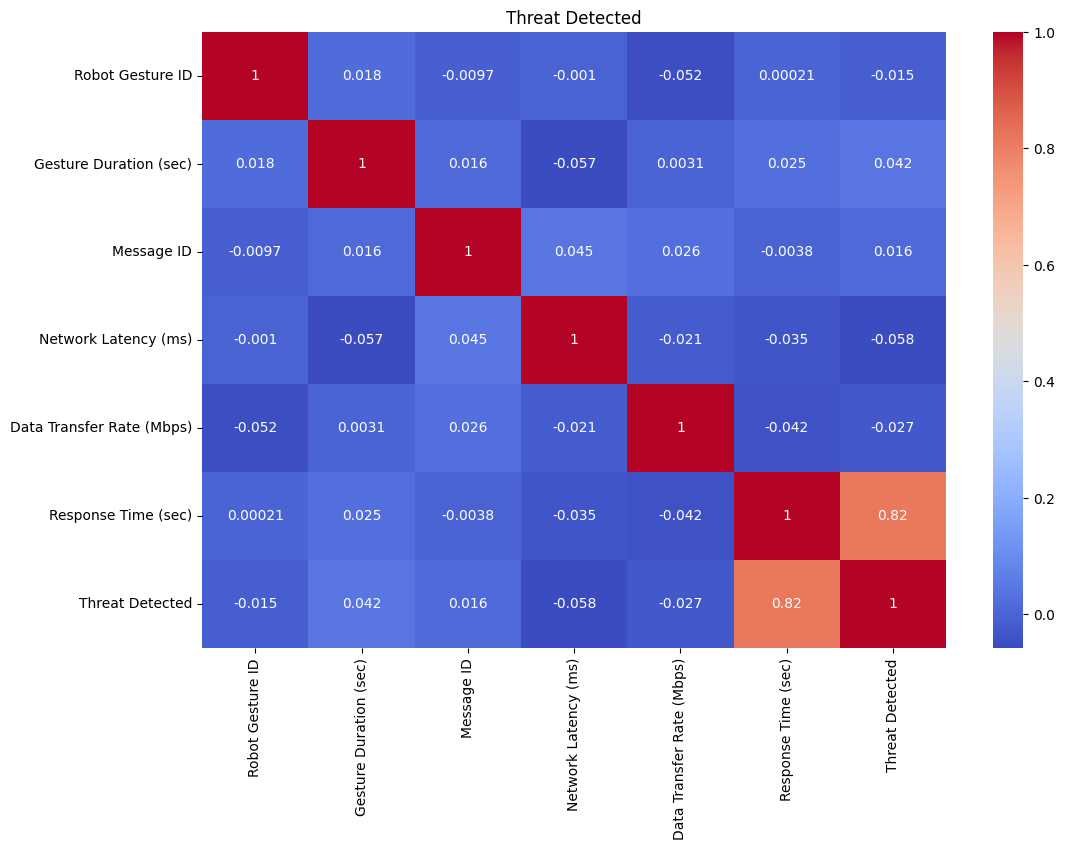

In [117]:
numeric_data = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Threat Detected")
plt.show()

In [118]:
xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    random_state=42)

In [119]:
x=pd.DataFrame(x)
x = pd.get_dummies(x, drop_first=True)

In [120]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=42)
xgb.fit(x_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [121]:
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)
model.fit(x_train, y_train)

from sklearn.metrics import classification_report
print(classification_report(y_test, model.predict(x_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.75      1.00      0.86       300

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.56      0.75      0.64       400



In [122]:
y_pred=gb.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1,

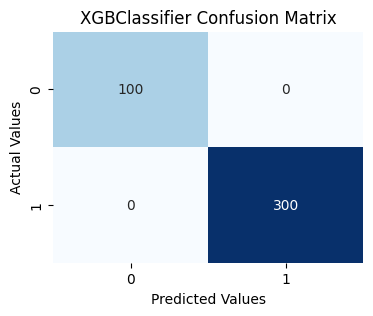

In [123]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("XGBClassifier Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [124]:
x=StandardScaler().fit_transform(x)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [125]:
model=SVC(kernel='rbf',C=1.0,gamma='scale')
model.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [126]:
model = SVC(C=10, kernel='rbf', gamma='scale')
model.fit(x_train, y_train)
ypred = model.predict(x_test)

In [127]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split first, then scale only training data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Train and evaluate in one go
model = SVC(kernel='rbf', C=0.5, gamma=1, random_state=42)  # lower C & custom gamma to reduce overfitting
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7566666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        73
           1       0.76      1.00      0.86       227

    accuracy                           0.76       300
   macro avg       0.38      0.50      0.43       300
weighted avg       0.57      0.76      0.65       300


Confusion Matrix:
 [[  0  73]
 [  0 227]]


In [128]:

model=SVC(kernel="linear")

In [129]:
model.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [130]:
model.score(x_test,y_test)

1.0

In [131]:
model.fit(x_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [132]:
y_pred=model.predict(x_test)
y_pred

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1])

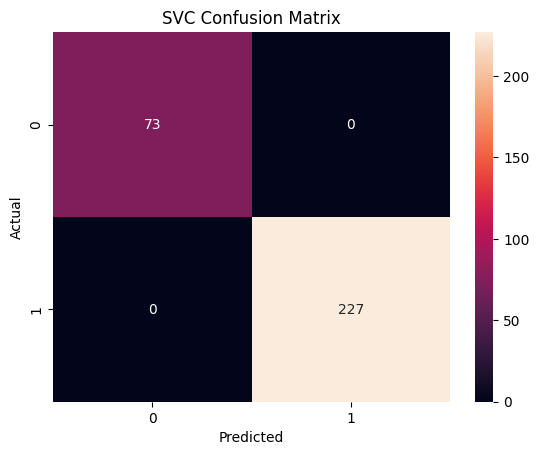

In [133]:
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVC Confusion Matrix")
plt.show()

In [134]:
iface = gr.Interface(
    fn=Threat_Detected_Predictor,
    inputs=[
        gr.Textbox(label="Robot Gesture ID"),
        gr.Textbox(label="Gesture Type"),
        gr.Textbox(label="Gesture Coordinates (x, y, z)"),
        gr.Textbox(label="Timestamp"),
        gr.Textbox(label="Gesture Duration (sec)"),
        gr.Textbox(label="Robot Status"),
        gr.Textbox(label="Message ID"),
        gr.Textbox(label="Sender"),
        gr.Textbox(label="Receiver"),
        gr.Textbox(label="Encryption Algorithm Used"),
        gr.Textbox(label="Encryption Status"),
        gr.Textbox(label="Network Latency (ms)"),
        gr.Textbox(label="Data Transfer Rate (Mbps)"),
        gr.Textbox(label="Threat Type"),
        gr.Textbox(label="Threat Severity"),
        gr.Textbox(label="Response Time (sec)"),
        gr.Textbox(label="Response Action Taken"),
        gr.Textbox(label="Threat Detected")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Threat Detected Predictor",
    description="Checking the possibility of Threat Detected."
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
